# **Checking Whether Email is Spam or Not**

In [1]:
# Import Libraries
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# Create Dataset
data = {
    "Email": [
        "Congratulations! You won a free iPhone",
        "Meeting at 10 AM tomorrow",
        "Claim your cash prize now",
        "Project submission deadline is today",
        "Win a lottery worth 10 lakh",
        "Lunch at 1 PM?",
        "Exclusive offer just for you",
        "Your salary has been credited",
        "Click here to get free gifts",
        "Team meeting has been postponed"
    ],

    "Label": [
        "Spam",
        "Not Spam",
        "Spam",
        "Not Spam",
        "Spam",
        "Not Spam",
        "Spam",
        "Not Spam",
        "Spam",
        "Not Spam"
    ]
}

df = pd.DataFrame(data)

print(df)

                                    Email     Label
0  Congratulations! You won a free iPhone      Spam
1               Meeting at 10 AM tomorrow  Not Spam
2               Claim your cash prize now      Spam
3    Project submission deadline is today  Not Spam
4             Win a lottery worth 10 lakh      Spam
5                          Lunch at 1 PM?  Not Spam
6            Exclusive offer just for you      Spam
7           Your salary has been credited  Not Spam
8            Click here to get free gifts      Spam
9         Team meeting has been postponed  Not Spam


In [3]:
# Convert Labels into Numbers
df["Label"] = df["Label"].map({
    "Spam":1,
    "Not Spam":0
})

In [4]:
# Split Dataset
X = df["Email"]
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Convert Text into Numbers
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [6]:
# Train the Model
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [7]:
# Make Predictions
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [8]:
# Test a New Email
new_email = ["Congratulations! Claim your free lottery prize now"]

new_email_vector = vectorizer.transform(new_email)

prediction = model.predict(new_email_vector)

if prediction[0] == 1:
    print("Spam Mail")
else:
    print("Not Spam")

Spam Mail


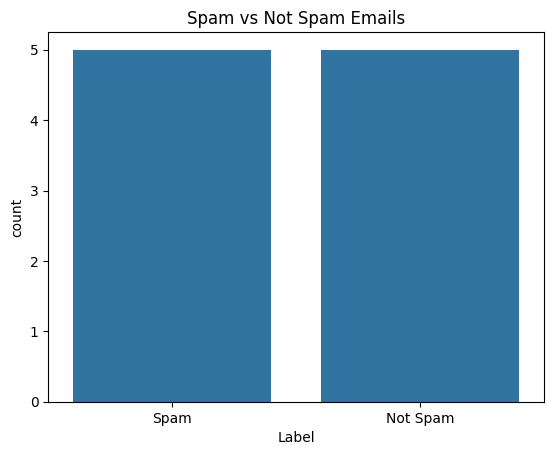

In [9]:
# Count Plot
import seaborn as sns
import matplotlib.pyplot as plt
df["Label"] = df["Label"].map({1:"Spam",0:"Not Spam"})

sns.countplot(x="Label", data=df)

plt.title("Spam vs Not Spam Emails")

plt.show()

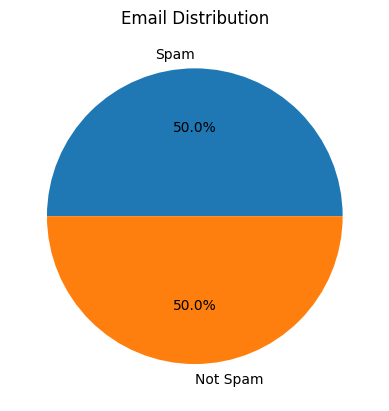

In [10]:
# Pie Chart
df["Label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Email Distribution")
plt.ylabel("")
plt.show()